# 07 — Publication Figures

Final, publication-quality figures and summary tables for the North Indian
Folk Music Rhythm Analysis project, built entirely from results already
produced by notebooks 01–06: the rhythm feature dataframe (Notebook 02),
the raw already-extracted `mel_spec` arrays (Notebook 01/02 convention),
and the tables saved by Notebooks 05 and 06. No audio is loaded, no new
features are extracted, and no new dataset is created here — this notebook
only reformats and re-renders existing results for publication.

Any requested figure that duplicates an already-produced result, or whose
required input is unavailable on disk, is skipped with an explicit comment
rather than invented.

In [1]:
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram

sys.path.append("..")
from utils.similarity import (
    get_feature_columns,
    compute_group_centroids,
    group_cosine_similarity,
    group_distance_matrix,
    top_similar_pairs,
    top_dissimilar_pairs,
)

RANDOM_STATE = 42


## Publication style configuration

In [2]:
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

GENRES = ["Bauls", "Bhatiali", "Gidha", "Kajri", "Maand", "Sohar", "Sufi", "Uttarakhandi"]
GENRE_PALETTE = dict(zip(GENRES, sns.color_palette("tab10", n_colors=len(GENRES))))


def save_fig(fig, name: str, directory: Path) -> None:
    path = directory / f"{name}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")


## Paths (reusing existing project conventions)

In [3]:
DATA_DIR = Path("../data")
FEATURES_PATH = Path("../data/extracted/rhythm_features.parquet")
TABLES_DIR = Path("../tables")
FIGURES_DIR = Path("../figures")

PUB_FIGURES_DIR = Path("../figures/publication")
PUB_TABLES_DIR = Path("../tables/publication")
PUB_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PUB_TABLES_DIR.mkdir(parents=True, exist_ok=True)

GENRE_FILES = [
    "Bauls_clean.pkl",
    "Bhatiali_clean.pkl",
    "Gidha_clean.pkl",
    "Kajri_clean.pkl",
    "Maand_clean.pkl",
    "Sohar_clean.pkl",
    "Sufi_clean.pkl",
    "Uttarakhandi_clean.pkl",
]


## Load rhythm feature dataframe (Notebook 02 output)

In [4]:
rhythm_df = pd.read_parquet(FEATURES_PATH)
metadata_cols = ["genre", "state", "artist", "gender", "song", "source", "source_file"]
metadata_cols = [c for c in metadata_cols if c in rhythm_df.columns]
feature_cols = get_feature_columns(rhythm_df, exclude=metadata_cols)

present_genres = [g for g in GENRES if g in rhythm_df["genre"].unique()]
rhythm_df.shape, len(feature_cols)


((109089, 41), 34)

## Figure 1 — Genre / dataset distribution

Saved: ..\figures\publication\figure01_genre_distribution.png


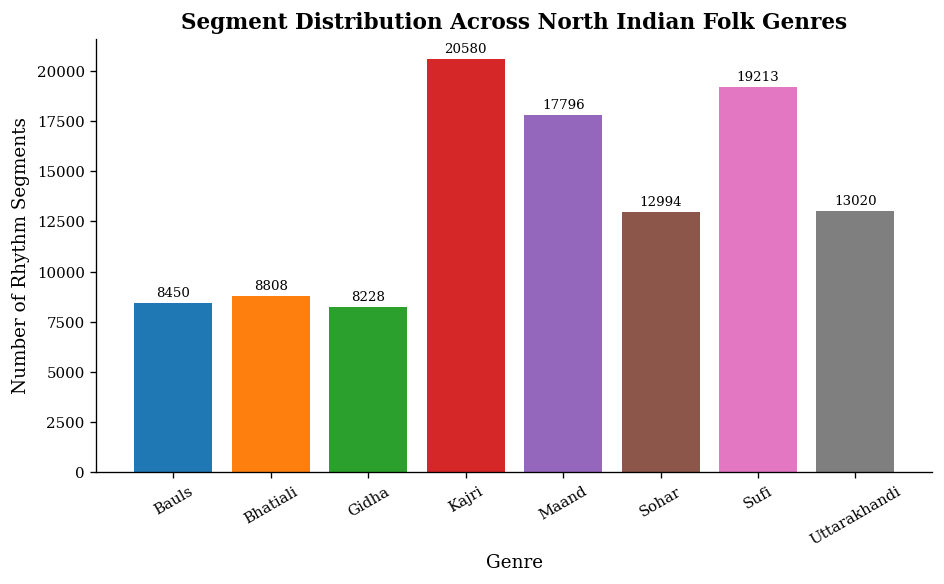

In [5]:
genre_counts = rhythm_df["genre"].value_counts().reindex(present_genres)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(genre_counts.index, genre_counts.values,
               color=[GENRE_PALETTE[g] for g in genre_counts.index])
ax.bar_label(bars, padding=2, fontsize=8)
ax.set_xlabel("Genre")
ax.set_ylabel("Number of Rhythm Segments")
ax.set_title("Segment Distribution Across North Indian Folk Genres")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
save_fig(fig, "figure01_genre_distribution", PUB_FIGURES_DIR)
plt.show()


## Figure 2 — Representative Mel spectrograms per genre

Built directly from the already-extracted `mel_spec` arrays in the raw
per-genre pickle files (same loading convention as Notebook 02: `DATA_DIR /
GENRE_FILES`). No audio is loaded and no spectrogram is recomputed — each
panel is the **mean of the existing `mel_spec` segments** for that genre,
included only if the raw pickle files are present on disk.

In [6]:
representative_specs = {}
mel_spec_available = True

for filename in GENRE_FILES:
    file_path = DATA_DIR / filename
    if not file_path.exists():
        mel_spec_available = False
        break
    with open(file_path, "rb") as f:
        data = pickle.load(f)
    genre_name = filename.replace("_clean.pkl", "")
    representative_specs[genre_name] = np.mean(data["mel_spec"], axis=0)

mel_spec_available


False

In [7]:
if mel_spec_available:
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    axes = axes.flatten()

    for ax, genre_name in zip(axes, representative_specs.keys()):
        spec = representative_specs[genre_name]
        im = ax.imshow(spec, origin="lower", aspect="auto", cmap="magma")
        ax.set_title(genre_name)
        ax.set_xlabel("Time Frame")
        ax.set_ylabel("Mel Bin")

    fig.suptitle("Mean Mel Spectrogram by Genre (Already-Extracted Segments)", y=1.02, fontweight="bold")
    fig.tight_layout()
    save_fig(fig, "figure02_representative_mel_spectrograms", PUB_FIGURES_DIR)
    plt.show()
else:
    print(
        "Skipped Figure 2: raw per-genre pickle files were not found at "
        f"{DATA_DIR}. This figure requires the original mel_spec arrays "
        "used by Notebook 02 and is not reconstructable from the rhythm "
        "feature dataframe alone."
    )


Skipped Figure 2: raw per-genre pickle files were not found at ..\data. This figure requires the original mel_spec arrays used by Notebook 02 and is not reconstructable from the rhythm feature dataframe alone.


## Figure 3 — Genre rhythm similarity (cosine) heatmap

Saved: ..\figures\publication\figure03_genre_cosine_similarity_heatmap.png


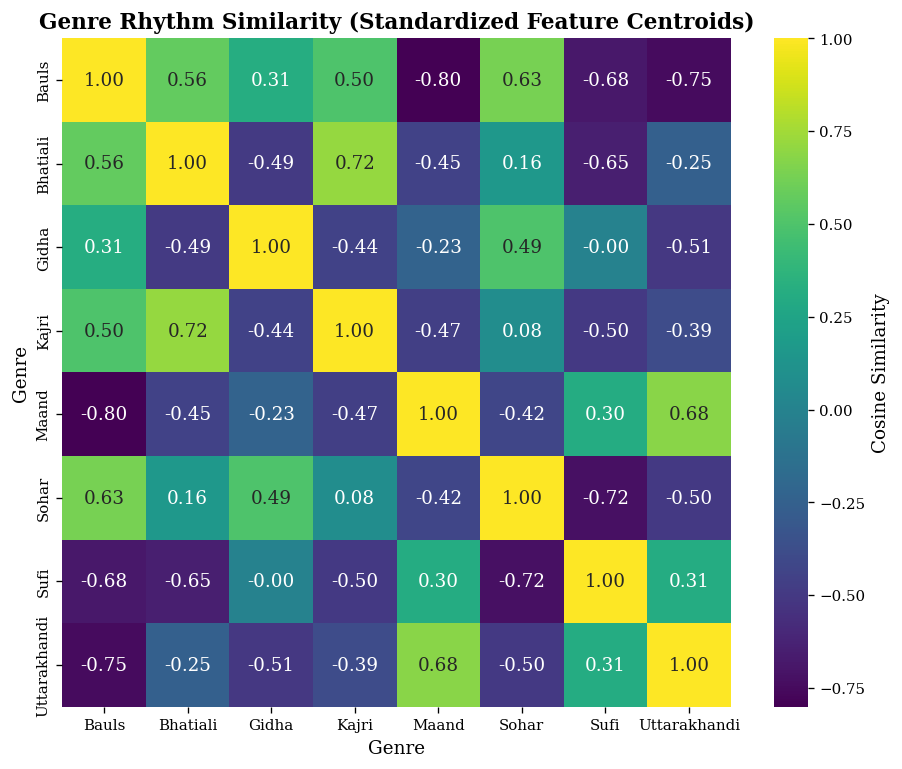

In [8]:
genre_cos_sim = group_cosine_similarity(rhythm_df, group_col="genre")
genre_cos_sim = genre_cos_sim.reindex(index=present_genres, columns=present_genres)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(genre_cos_sim, annot=True, fmt=".2f", cmap="viridis", square=True,
            cbar_kws={"label": "Cosine Similarity"}, ax=ax)
ax.set_title("Genre Rhythm Similarity (Standardized Feature Centroids)")
ax.set_xlabel("Genre")
ax.set_ylabel("Genre")
fig.tight_layout()
save_fig(fig, "figure03_genre_cosine_similarity_heatmap", PUB_FIGURES_DIR)
plt.show()


## Figure 4 — Genre Euclidean-distance heatmap

Saved: ..\figures\publication\figure04_genre_euclidean_distance_heatmap.png


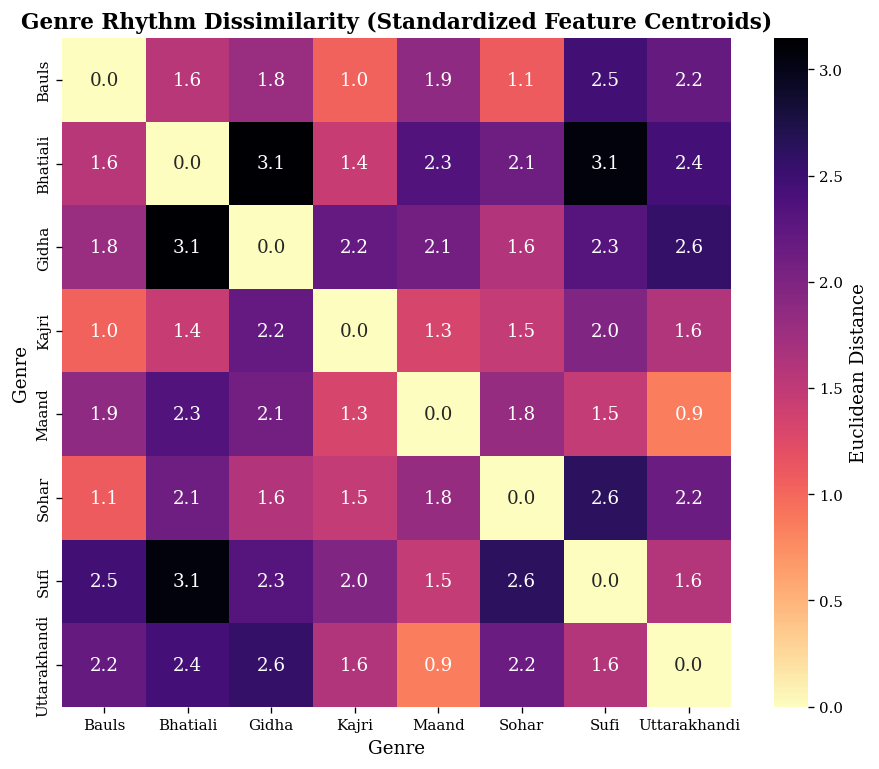

In [9]:
genre_dist = group_distance_matrix(rhythm_df, group_col="genre", metric="euclidean")
genre_dist = genre_dist.reindex(index=present_genres, columns=present_genres)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(genre_dist, annot=True, fmt=".1f", cmap="magma_r", square=True,
            cbar_kws={"label": "Euclidean Distance"}, ax=ax)
ax.set_title("Genre Rhythm Dissimilarity (Standardized Feature Centroids)")
ax.set_xlabel("Genre")
ax.set_ylabel("Genre")
fig.tight_layout()
save_fig(fig, "figure04_genre_euclidean_distance_heatmap", PUB_FIGURES_DIR)
plt.show()


## Genre pair tables (from Figures 3–4 similarity results)

In [10]:
most_similar_pairs_df = top_similar_pairs(genre_cos_sim, n=5)
most_dissimilar_pairs_df = top_dissimilar_pairs(genre_cos_sim, n=5)

most_similar_pairs_df.to_csv(PUB_TABLES_DIR / "most_similar_genre_pairs.csv", index=False)
most_dissimilar_pairs_df.to_csv(PUB_TABLES_DIR / "most_dissimilar_genre_pairs.csv", index=False)

most_similar_pairs_df


,group_a,group_b,similarity
0,Bhatiali,Kajri,0.716452
1,Maand,Uttarakhandi,0.683451
2,Bauls,Sohar,0.627877
3,Bauls,Bhatiali,0.564350
4,Bauls,Kajri,0.499975


In [11]:
most_dissimilar_pairs_df


,group_a,group_b,similarity
0,Bauls,Maand,-0.800475
1,Bauls,Uttarakhandi,-0.745812
2,Sohar,Sufi,-0.723418
3,Bauls,Sufi,-0.682978
4,Bhatiali,Sufi,-0.646216


## Balanced visualization sample (for Figures 5, 6, 8)

In [12]:
MAX_PER_GENRE = 800

def balanced_sample(df: pd.DataFrame, group_col: str, max_per_group: int, random_state: int) -> pd.DataFrame:
    return (
        df.groupby(group_col, group_keys=False)
        .apply(lambda g: g.sample(n=min(len(g), max_per_group), random_state=random_state))
        .reset_index(drop=True)
    )

scaler = StandardScaler()
X_scaled = scaler.fit_transform(rhythm_df[feature_cols].to_numpy())

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca_2d.fit_transform(X_scaled)

pca_df = rhythm_df[metadata_cols].copy()
pca_df["pc1"] = pca_coords[:, 0]
pca_df["pc2"] = pca_coords[:, 1]

viz_sample_df = balanced_sample(pca_df, "genre", MAX_PER_GENRE, RANDOM_STATE)
len(viz_sample_df), pca_2d.explained_variance_ratio_


C:\Users\ankit\AppData\Local\Temp\ipykernel_19452\1379891091.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), max_per_group), random_state=random_state))


(6400, array([0.27926185, 0.21687259]))

## Figure 5 — PCA of rhythm features, colored by genre

Saved: ..\figures\publication\figure05_pca_by_genre.png


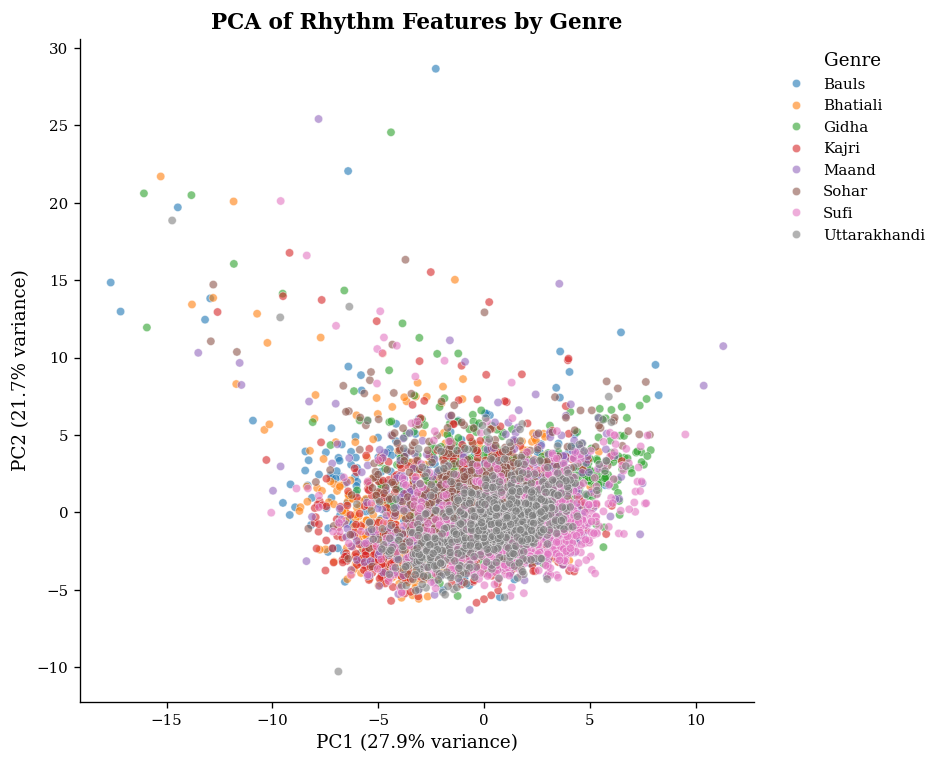

In [13]:
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.scatterplot(
    data=viz_sample_df, x="pc1", y="pc2", hue="genre",
    palette=GENRE_PALETTE, alpha=0.6, s=25, ax=ax,
)
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("PCA of Rhythm Features by Genre")
ax.legend(title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
save_fig(fig, "figure05_pca_by_genre", PUB_FIGURES_DIR)
plt.show()


## Figure 6 — PCA of rhythm features, colored by state (only if meaningful)

In [14]:
genre_state_crosstab = pd.crosstab(rhythm_df["genre"], rhythm_df["state"])
genres_per_state = (genre_state_crosstab > 0).sum(axis=0)
states_per_genre = (genre_state_crosstab > 0).sum(axis=1)
state_meaningful = bool((genres_per_state > 1).sum() >= 2 and (states_per_genre > 1).any())

if state_meaningful:
    fig, ax = plt.subplots(figsize=(8, 6.5))
    sns.scatterplot(
        data=viz_sample_df, x="pc1", y="pc2", hue="state",
        palette="tab10", alpha=0.6, s=25, ax=ax,
    )
    ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
    ax.set_title("PCA of Rhythm Features by State")
    ax.legend(title="State", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    fig.tight_layout()
    save_fig(fig, "figure06_pca_by_state", PUB_FIGURES_DIR)
    plt.show()
else:
    print(
        "Skipped Figure 6: genre and state are effectively confounded in "
        "this dataset (per the crosstab above), so a state-colored PCA plot "
        "would not show anything separable from Figure 5 and would be "
        "misleading to present as an independent regional pattern."
    )


Skipped Figure 6: genre and state are effectively confounded in this dataset (per the crosstab above), so a state-colored PCA plot would not show anything separable from Figure 5 and would be misleading to present as an independent regional pattern.


## Figure 7 — Hierarchical clustering dendrogram of genre rhythm profiles

Saved: ..\figures\publication\figure07_genre_hierarchical_dendrogram.png


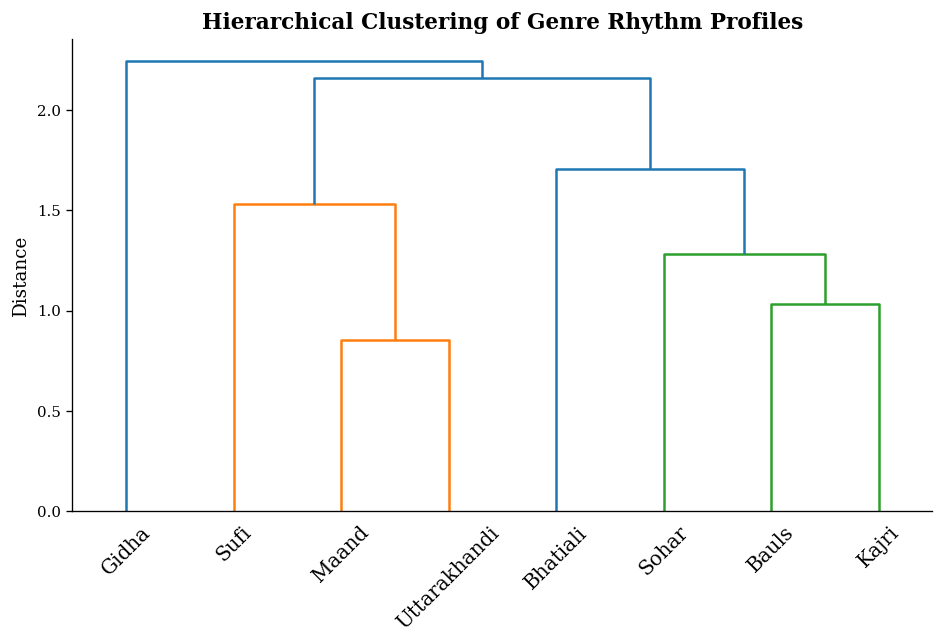

In [15]:
genre_centroids, _ = compute_group_centroids(rhythm_df, group_col="genre", feature_cols=feature_cols, normalize=True)
genre_centroids = genre_centroids.reindex(present_genres)

linkage_matrix = linkage(genre_centroids.to_numpy(), method="average", metric="euclidean")

fig, ax = plt.subplots(figsize=(8, 5.5))
dendrogram(linkage_matrix, labels=genre_centroids.index.tolist(), leaf_rotation=45, ax=ax)
ax.set_ylabel("Distance")
ax.set_title("Hierarchical Clustering of Genre Rhythm Profiles")
fig.tight_layout()
save_fig(fig, "figure07_genre_hierarchical_dendrogram", PUB_FIGURES_DIR)
plt.show()


## Figure 8 — K-Means clustering in PCA space (K reused from Notebook 05)

C:\Users\ankit\AppData\Local\Temp\ipykernel_19452\1379891091.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), max_per_group), random_state=random_state))


Saved: ..\figures\publication\figure08_kmeans_clusters_pca.png


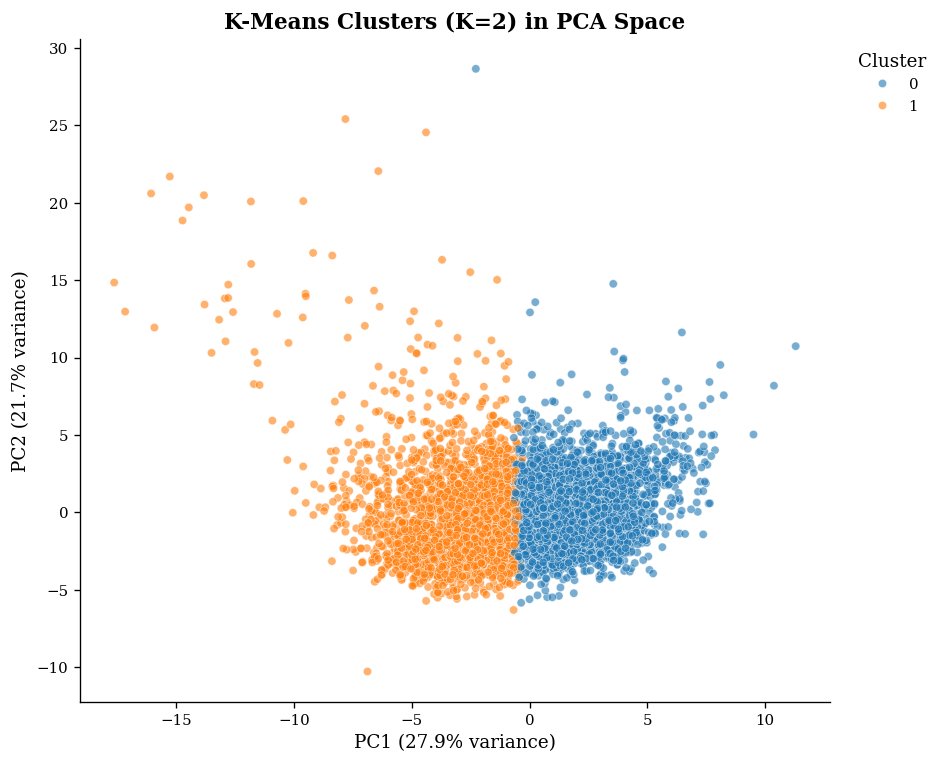

In [16]:
kmeans_eval_path = TABLES_DIR / "kmeans_evaluation_metrics.csv"

if kmeans_eval_path.exists():
    kmeans_eval_df = pd.read_csv(kmeans_eval_path)
    best_k = int(kmeans_eval_df.loc[kmeans_eval_df["silhouette_score"].idxmax(), "k"])

    final_kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
    cluster_labels = final_kmeans.fit_predict(X_scaled)
    pca_df["cluster"] = cluster_labels
    viz_sample_df = balanced_sample(pca_df, "genre", MAX_PER_GENRE, RANDOM_STATE)

    fig, ax = plt.subplots(figsize=(8, 6.5))
    sns.scatterplot(
        data=viz_sample_df, x="pc1", y="pc2", hue="cluster",
        palette="tab10", alpha=0.6, s=25, ax=ax,
    )
    ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
    ax.set_title(f"K-Means Clusters (K={best_k}) in PCA Space")
    ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    fig.tight_layout()
    save_fig(fig, "figure08_kmeans_clusters_pca", PUB_FIGURES_DIR)
    plt.show()
else:
    print(
        f"Skipped Figure 8: {kmeans_eval_path} not found. This figure "
        "reuses the K selected in Notebook 05 (05_Clustering_Analysis.ipynb) "
        "and is not regenerated with an independently chosen K."
    )


## Figure 9 — Top statistically significant rhythm features (Notebook 06)

C:\Users\ankit\miniconda3\envs\ml\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Saved: ..\figures\publication\figure09_top_significant_features.png


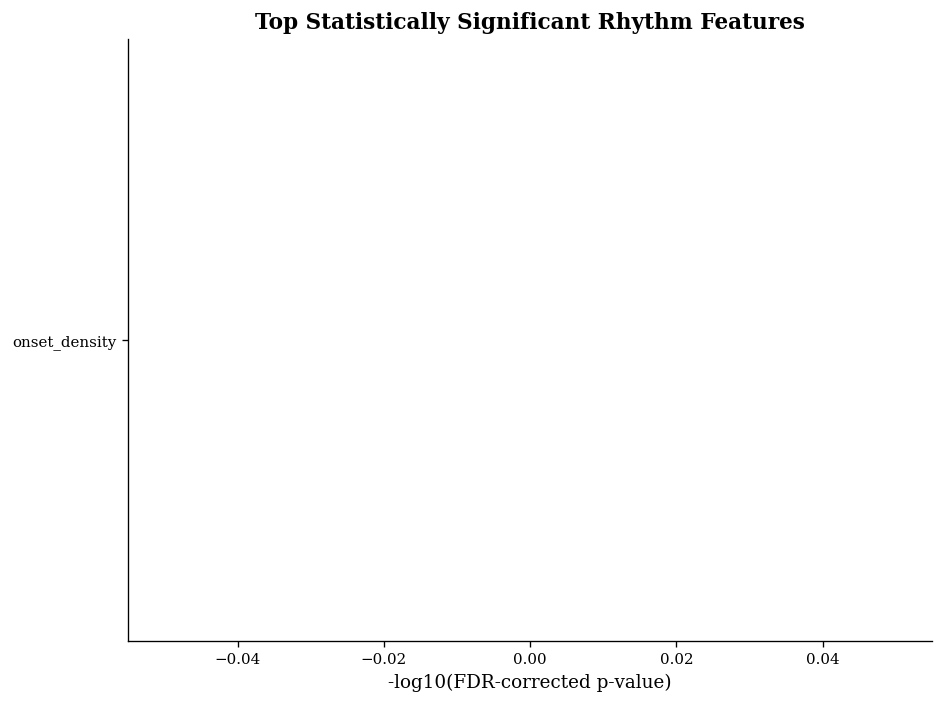

In [17]:
ranked_features_path = TABLES_DIR / "ranked_significant_features.csv"

if ranked_features_path.exists():
    ranked_features_df = pd.read_csv(ranked_features_path)
    TOP_N = 10
    top_plot_df = ranked_features_df.head(TOP_N).iloc[::-1]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top_plot_df["feature"], -np.log10(top_plot_df["p_value_fdr_bh"]), color="steelblue")
    ax.set_xlabel("-log10(FDR-corrected p-value)")
    ax.set_title("Top Statistically Significant Rhythm Features")
    fig.tight_layout()
    save_fig(fig, "figure09_top_significant_features", PUB_FIGURES_DIR)
    plt.show()

    top_features = ranked_features_df["feature"].head(6).tolist()
else:
    print(
        f"Skipped Figure 9: {ranked_features_path} not found. This figure "
        "requires the FDR-corrected Kruskal-Wallis ranking produced by "
        "06_Statistical_Analysis.ipynb."
    )
    top_features = []


## Figure 10 — Distributions of the strongest rhythm features by genre

C:\Users\ankit\AppData\Local\Temp\ipykernel_19452\4102435868.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ankit\AppData\Local\Temp\ipykernel_19452\4102435868.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ankit\AppData\Local\Temp\ipykernel_19452\4102435868.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ankit\AppData\Local\Temp\ipykernel_19452\4102435868.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable 

Saved: ..\figures\publication\figure10_top_features_by_genre.png


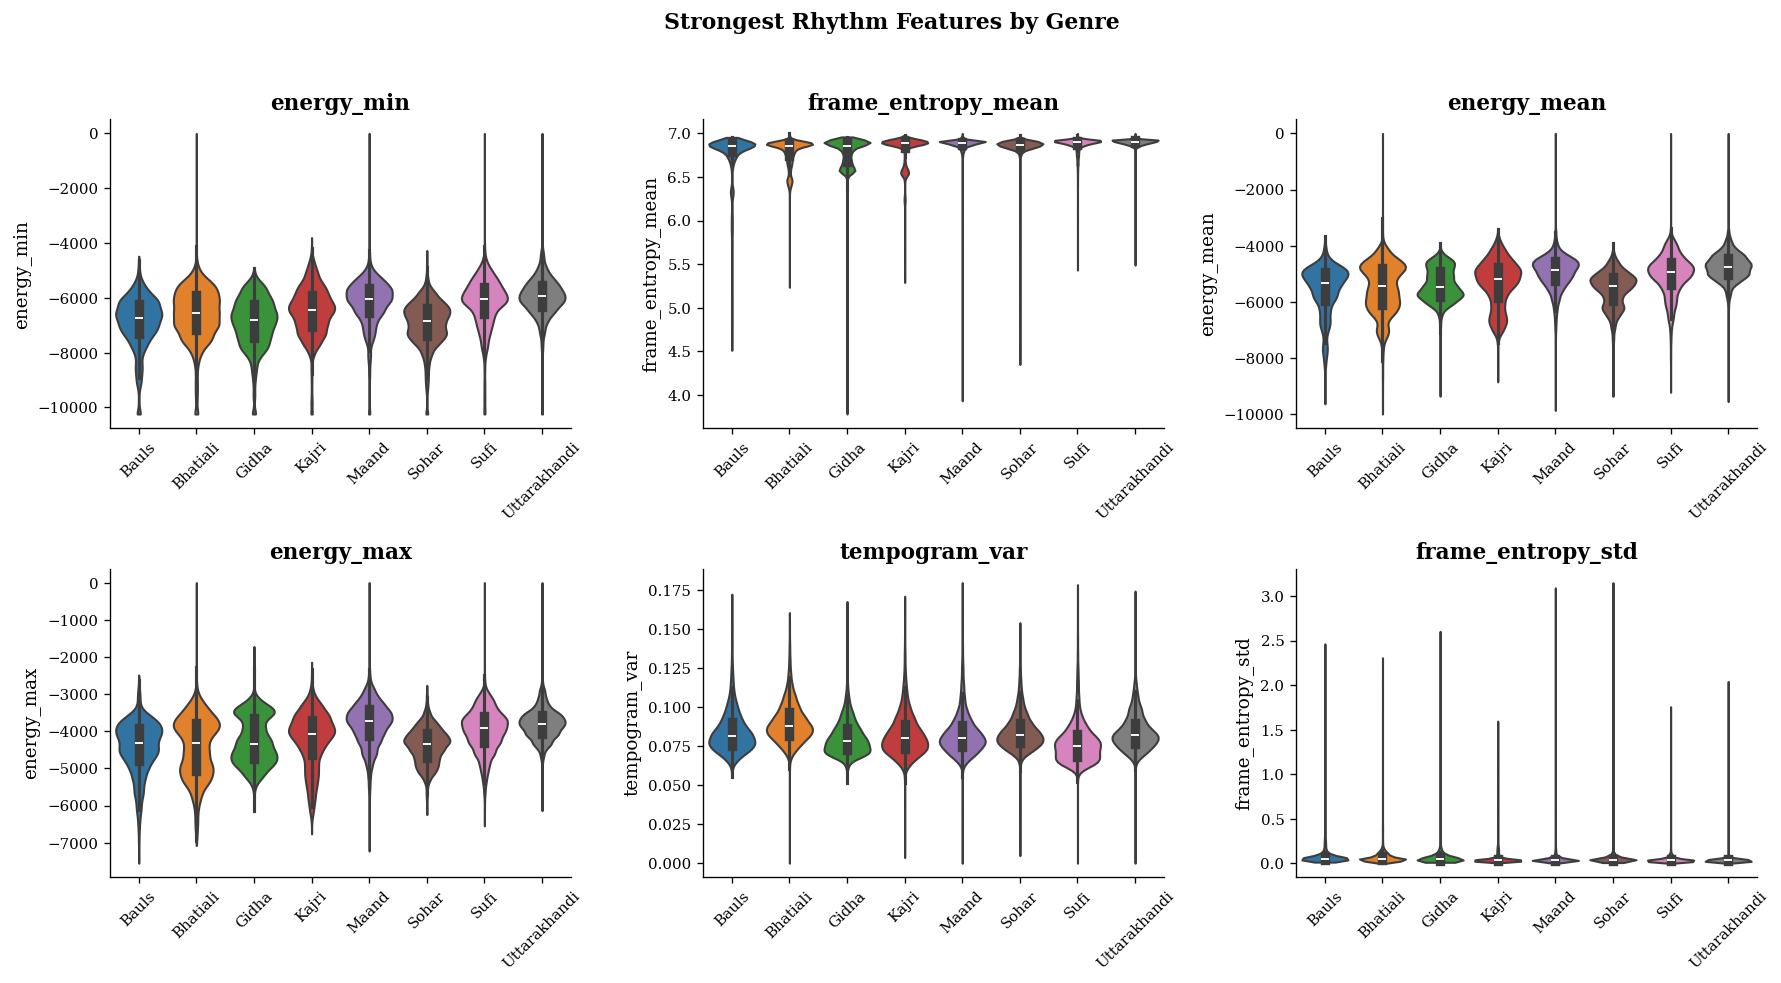

In [18]:
if top_features:
    n_plot = min(6, len(top_features))
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for ax, feature in zip(axes, top_features[:n_plot]):
        sns.violinplot(
            data=rhythm_df, x="genre", y=feature, order=present_genres,
            palette=GENRE_PALETTE, inner="box", cut=0, ax=ax,
        )
        ax.set_title(feature)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=45)

    for ax in axes[n_plot:]:
        ax.axis("off")

    fig.suptitle("Strongest Rhythm Features by Genre", y=1.02, fontweight="bold")
    fig.tight_layout()
    save_fig(fig, "figure10_top_features_by_genre", PUB_FIGURES_DIR)
    plt.show()
else:
    print("Skipped Figure 10: no significant features available from Notebook 06 to plot.")


## Publication table — genre-level rhythm summary

In [19]:
descriptive_path = TABLES_DIR / "descriptive_statistics_by_genre.csv"

if descriptive_path.exists() and top_features:
    descriptive_df = pd.read_csv(descriptive_path)
    summary_subset = descriptive_df[descriptive_df["feature"].isin(top_features)]
    genre_summary_table = summary_subset.pivot(index="genre", columns="feature", values="mean")
    genre_summary_table = genre_summary_table.reindex(present_genres).round(3)
    genre_summary_table.to_csv(PUB_TABLES_DIR / "genre_rhythm_summary.csv")
    genre_summary_table
else:
    print(f"Skipped genre-level summary table: {descriptive_path} or significant-feature list unavailable.")


## Publication table — statistically significant rhythm features

In [20]:
significant_path = TABLES_DIR / "significant_features_after_fdr.csv"

if significant_path.exists():
    significant_df = pd.read_csv(significant_path)
    significant_pub_df = significant_df[["feature", "H_statistic", "p_value_fdr_bh", "eta_squared_H"]].round(4)
    significant_pub_df.to_csv(PUB_TABLES_DIR / "significant_rhythm_features.csv", index=False)
    significant_pub_df
else:
    print(f"Skipped significant-features table: {significant_path} not found.")


## Publication table — clustering evaluation results

In [21]:
if kmeans_eval_path.exists():
    kmeans_eval_pub_df = kmeans_eval_df.round(4)
    kmeans_eval_pub_df.to_csv(PUB_TABLES_DIR / "clustering_evaluation_results.csv", index=False)
    kmeans_eval_pub_df
else:
    print(f"Skipped clustering evaluation table: {kmeans_eval_path} not found.")


## Summary

Figures and tables above are written to `../figures/publication/` and
`../tables/publication/` respectively, at 300 DPI PNG for figures. Any
figure or table skipped above is skipped because its required upstream
result was not found on disk (i.e. the corresponding notebook has not yet
been run / saved its outputs) or because the requested regional comparison
would be misleading given the genre–state relationship in this dataset —
not because it was omitted arbitrarily.